<a href="https://colab.research.google.com/github/maida-xaashi/Bile-Initiative/blob/main/Frist_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Frist Coursework

## Import pandas

In [7]:
import pandas as pd

## Read Data

In [8]:
data=pd.read_csv("student_cleaning_practice_200_v2.csv",sep=",")

## Checking Null

In [16]:
data.isna().sum()

,0
student_id,0
name,0
age,12
gender,10
school,0
city,8
study_hours_per_day,0
attendance_percent,11
internet_access,0
parent_support,0


## Fill null values

In [19]:
data[['exam_score', 'age']] = data[['exam_score', 'age']].fillna(data[['exam_score', 'age']].mean())


In [23]:
data['city'] = data['city'].fillna(data['city'].mode()[0])
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])
data['attendance_percent'] = data['attendance_percent'].fillna(data['attendance_percent'].median())

In [24]:
data.isna().sum()

,0
student_id,0
name,0
age,0
gender,0
school,0
city,0
study_hours_per_day,0
attendance_percent,0
internet_access,0
parent_support,0


## Check duplicate value

In [27]:
data.duplicated().sum()

np.int64(10)

## Drop duplicate Value

In [28]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

## Add Colum

In [29]:
data["at_risk"] = (data["exam_score"] <= 50).astype(int)

## Feature and Target Selection

In [31]:
feature = [
    'study_hours_per_day', 'attendance_percent', 'internet_access',
    'parent_support', 'absences'
]

x = data[feature].copy()
y = data["at_risk"].copy()

In [30]:
data.head()

,student_id,name,age,gender,school,city,study_hours_per_day,attendance_percent,internet_access,parent_support,absences,exam_score,grade,at_risk
0,STU034,Abdi Mohamed,19.0,Male,Bile Academy,Baidoa,4,87.0,No,No,3,69.0,C,0
1,STU086,Yusuf Yusuf,22.0,Male,Hodan School,Kismayo,5,87.0,No,No,0,98.0,A,0
2,STU057,Yusuf Hassan,18.0,Female,Hamar School,Baidoa,2,95.0,No,No,0,50.0,D,1
3,STU105,Hodan Yusuf,20.0,Female,Bile Academy,Garowe,5,84.0,No,Yes,6,54.0,D,0
4,STU121,Ifrah Warsame,17.0,Male,Hamar School,Mogadishu,3,70.0,Yes,Yes,7,90.0,A,0


In [32]:
y.value_counts()

,count
at_risk,
0,165
1,25


## Chart

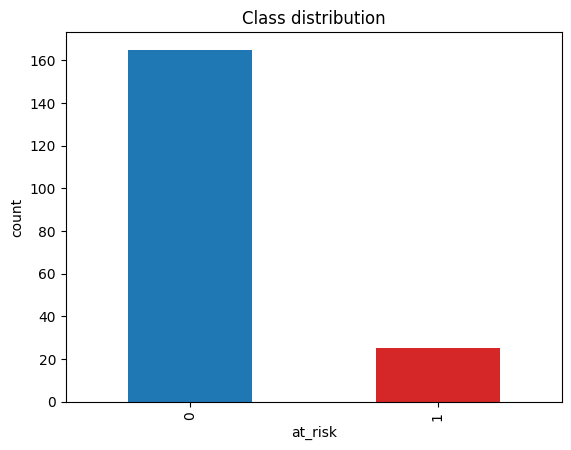

In [34]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar", color=['#1f77b4', '#d62728'])
plt.xlabel("at_risk")
plt.ylabel("count")
plt.title("Class distribution")
plt.show()